# 08 · Consensus of the pipelines

**Question.** If a variant is kept when at least n pipelines call it, which n gives the best F1-score against the high-confidence variant set, and how much does the consensus improve on the best single pipeline?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (the variant set of each run), `data/reference/TestCases.csv` and the truth VCF `data/truth/hc_bed_filtered.recode.vcf`. It never reads `data/raw/`; no run VCF is parsed.

**Method (the legacy cells 203 to 211).**
1. The 480 runs are reduced to 120 pipelines: 5 samples (centers) x 2 mappers x 3 callers x 2 trimming x 2 base recalibration. Environment and duplicate handling are dropped: each group of four runs that differ only in them gives one pipeline, its first run in run order, as legacy does. The audit checks that the choice does not matter.
2. Every variant called by any of the 120 pipelines gets a support count, the number of pipelines that call it.
3. For n = 1 to 120, the consensus is the set of variants with support at least n (and, separately, exactly n). Its precision, recall and F1 are computed against the truth set, with the definitions of notebook 05.
4. The optimum is the first n with the highest F1 (the legacy `idxmax`), and the gain is its F1 against the best single pipeline.

**SomaticSniper asymmetry.** SomaticSniper VCFs have `FILTER = .` on every record, so the PASS filter is not applied to them (legacy behaviour); Mutect and Strelka are PASS-filtered. The votes of the 40 SomaticSniper pipelines inherit this.

**Produces** (`results/08_consensus/`):
- `tables/consensus_curve.csv`: for n = 1 to 120, the consensus size, true positives, precision, recall and F1, for "at least n" (`_ge`) and "exactly n" (`_eq`).
- `tables/consensus_best.csv`: the optimum, and its gain over the best single pipeline.
- `tables/pipelines.csv`: the 120 pipelines with their run, settings, variant count, precision, recall and F1.
- `figures/consensus_performance`: F1, recall and precision against n, with the maximum marked.

**Reproduction.** The legacy consensus cells were never executed in the legacy notebook, so it recorded no output. Parity checks that the whole curve equals the legacy functions (`ensemble_call`, `precision`, `recall`, `f1`) at every n, and compares the results with the values in the manuscript text (F1 0.94, at least 34 pipelines, +1.97%). Part of that does not reproduce: the maximum is at n = 33 and the +1.97% is computed from the rounded F1 (D16). The audit says which.

**Does not.** Change the counting rule, use the "at most n" sets of legacy (they were never plotted), or repeat the analysis by center (that uses `fraction_to_count`, D10).

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("08_consensus")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
PIPELINE = config.PIPELINE_FACTORS  # what defines a pipeline (legacy cell 203)
# Values in the manuscript text (given by the author): 120 pipelines, F1 0.94 with variants called by at least 34, +1.97%
MANUSCRIPT = {"pipelines": 120, "f1": 0.94, "n": 34, "gain_pct": 1.97}

## Load + validate

In [3]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)

meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME).reset_index()
assert runs["run"].is_monotonic_increasing  # the row order that "first run of a group" refers to

truth = io.truth_set(str(config.TRUTH_VCF))
assert len(truth) > 0
print("{} runs, {} truth variants".format(len(runs), len(truth)))

480 runs, 1161 truth variants


## Analysis

In [4]:
groups = runs.groupby(PIPELINE, sort=True)
assert groups.ngroups == MANUSCRIPT["pipelines"] == 120, groups.ngroups
assert (groups.size() == len(LEVELS["Environment"]) * len(LEVELS["Duplicates"])).all(), "a pipeline without its four runs"
selected = io.pipeline_runs(runs, PIPELINE)   # the first run of each group, in run order
pipeline_sets = {k: sets[k] for k in selected["TestCaseNo"]}

scores = pd.DataFrame([metrics.prf1(pipeline_sets[k], truth) for k in selected["TestCaseNo"]],
                      columns=["precision", "recall", "f1"])
pipelines = pd.concat([selected[["run"] + PIPELINE],
                       pd.Series([len(pipeline_sets[k]) for k in selected["TestCaseNo"]], name="n_variants"), scores], axis=1)
assert len(pipelines) == 120 and pipelines["run"].is_unique
pipelines.sort_values("f1", ascending=False).head(3)

,run,Sample,Mapper,VariantCaller,isTrimmed,baseRecalibration,n_variants,precision,recall,f1
103,776,IL,BOWTIE,Mutect,NO,YES,1039,0.975938,0.873385,0.921818
100,773,IL,BOWTIE,Mutect,YES,YES,1054,0.966793,0.877692,0.920090
99,772,IL,BWA,Mutect,NO,YES,1132,0.925795,0.902670,0.914086


In [5]:
curve = metrics.consensus_curve(pipeline_sets, truth)
union_size = len(set().union(*pipeline_sets.values()))
assert len(curve) == len(pipeline_sets) and curve["size_ge"].iloc[0] == union_size
assert curve["size_ge"].is_monotonic_decreasing and curve["size_eq"].sum() == union_size

best = curve.loc[curve["f1_ge"].idxmax()]                     # the first maximum, as the legacy idxmax
best_individual = pipelines.loc[pipelines["f1"].idxmax()]
at_manuscript_n = curve.loc[curve["n"] == MANUSCRIPT["n"]].iloc[0]
gain_absolute = best["f1_ge"] - best_individual["f1"]
gain_relative_pct = gain_absolute / best_individual["f1"] * 100
best_table = pd.DataFrame([{
    "n_pipelines": len(pipeline_sets), "best_n": int(best["n"]), "best_n_fraction": best["n"] / len(pipeline_sets),
    "consensus_size": int(best["size_ge"]), "precision": best["precision_ge"], "recall": best["recall_ge"],
    "f1": best["f1_ge"], "best_individual_run": int(best_individual["run"]), "best_individual_f1": best_individual["f1"],
    "gain_absolute": gain_absolute, "gain_relative_pct": gain_relative_pct,
    "f1_at_manuscript_n": at_manuscript_n["f1_ge"],
}])
curve[curve["n"].between(28, 40)][["n", "size_ge", "precision_ge", "recall_ge", "f1_ge"]].round(4)

,n,size_ge,precision_ge,recall_ge,f1_ge
27,28,1140,0.9465,0.9294,0.9379
28,29,1132,0.9505,0.9268,0.9385
29,30,1130,0.9504,0.9251,0.9376
30,31,1119,0.9571,0.9225,0.9395
31,32,1116,0.9588,0.9216,0.9398
32,33,1107,0.9639,0.9190,0.9409
33,34,1105,0.9647,0.9182,0.9409
34,35,1098,0.9672,0.9147,0.9402
35,36,1089,0.9706,0.9104,0.9396
36,37,1083,0.9741,0.9087,0.9403


In [6]:
# Does the choice of the representative of a group of four runs matter? Take each of the four (environment, duplicates)
# combinations for every pipeline and compare the F1 curves with the one above.
spread = []
for env in LEVELS["Environment"]:
    for dup in LEVELS["Duplicates"]:
        alt = runs[(runs["Environment"] == env) & (runs["Duplicates"] == dup)].groupby(PIPELINE, sort=True)["TestCaseNo"].first()
        assert len(alt) == 120
        curve_alt = metrics.consensus_curve({k: sets[k] for k in alt}, truth)
        spread.append(float((curve_alt["f1_ge"] - curve["f1_ge"]).abs().max()))
max_spread = max(spread)
print("largest F1 difference over n between the four representative choices: {:.2e}".format(max_spread))

largest F1 difference over n between the four representative choices: 1.79e-05


## Save tables

Written to staging; moved to `results/08_consensus/` only if parity passes.

In [7]:
io.write_csv(curve, STAGE.path(OUT / "tables" / "consensus_curve.csv"), sort_by="n")
io.write_csv(best_table, STAGE.path(OUT / "tables" / "consensus_best.csv"), sort_by="best_n")
io.write_csv(pipelines, STAGE.path(OUT / "tables" / "pipelines.csv"), sort_by="run")

## Figures

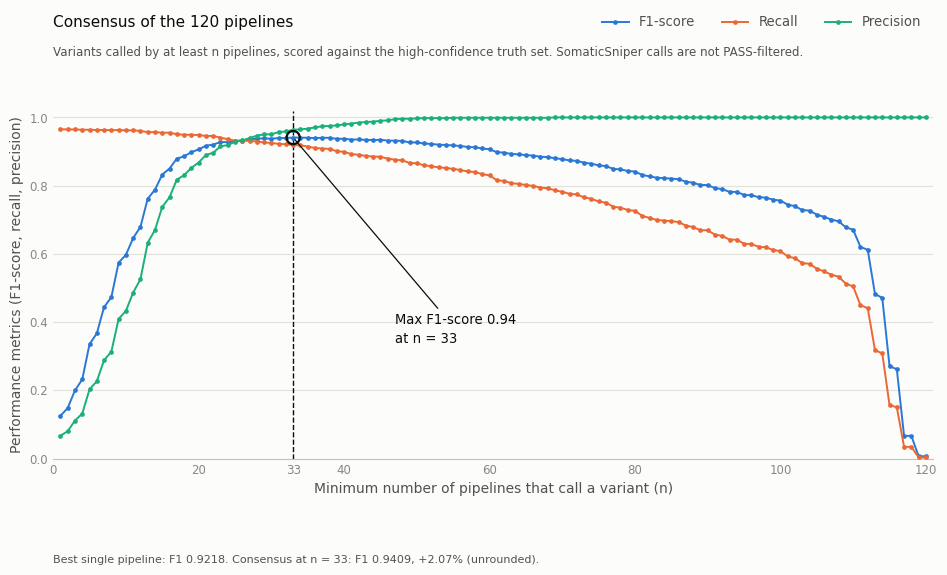

In [8]:
fig, ax = viz.consensus_performance(
    curve, title="Consensus of the 120 pipelines",
    subtitle="Variants called by at least n pipelines, scored against the high-confidence truth set. SomaticSniper calls are not PASS-filtered.",
    footnote="Best single pipeline: F1 {:.4f}. Consensus at n = {}: F1 {:.4f}, {:+.2f}% (unrounded).".format(
        best_individual["f1"], int(best["n"]), best["f1_ge"], gain_relative_pct))
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "consensus_performance"))
plt.show()

## Parity check

- The whole curve equals the legacy functions at every n: `ensemble_call` for "at least n" and "exactly n", scored with `precision`, `recall` and `f1`, exactly.
- The manuscript text: 120 pipelines; the maximum F1 rounds to its 0.94; the F1 at its n = 34 rounds to 0.94 and is within 1e-4 of the maximum; its +1.97% is reproduced from the rounded 0.94 and the best single pipeline.
- What does not reproduce is listed as such: the maximum is at n = 33, not 34, and the gain from the unrounded F1 is larger than 1.97% (D16).

Results are moved out of staging only if every check that ran passes.

In [9]:
parity = audit.Parity()
all_sets = list(pipeline_sets.values())

# The vectorised curve against the ported legacy functions, exactly
mismatch = []
for row in curve.itertuples():
    for mode in ("ge", "eq"):
        called = metrics.ensemble_call(all_sets, row.n, mode)
        expected = (len(called), len(called & truth))
        got = (getattr(row, "size_" + mode), getattr(row, "tp_" + mode))
        if called:
            expected += metrics.prf1(called, truth)
            got += (getattr(row, "precision_" + mode), getattr(row, "recall_" + mode), getattr(row, "f1_" + mode))
        if expected != got:
            mismatch.append((row.n, mode))
parity.check("consensus curve == ensemble_call scored with precision, recall and f1, at every n (ge and eq)",
             not mismatch, "{} of {} differ".format(len(mismatch), 2 * len(curve)))

# The manuscript text
parity.check("{} pipelines (5 centers x 2 x 2 x 2 x 3)".format(MANUSCRIPT["pipelines"]), len(pipeline_sets) == MANUSCRIPT["pipelines"],
             "{} pipelines".format(len(pipeline_sets)))
parity.check("the maximum F1 rounds to the manuscript's {}".format(MANUSCRIPT["f1"]), round(best["f1_ge"], 2) == MANUSCRIPT["f1"],
             "{:.4f}".format(best["f1_ge"]))
parity.check("F1 at the manuscript's n = {} rounds to {} and is within 1e-4 of the maximum".format(MANUSCRIPT["n"], MANUSCRIPT["f1"]),
             round(at_manuscript_n["f1_ge"], 2) == MANUSCRIPT["f1"] and best["f1_ge"] - at_manuscript_n["f1_ge"] <= 1e-4,
             "F1 {:.5f}, maximum {:.5f}".format(at_manuscript_n["f1_ge"], best["f1_ge"]))
from_rounded = (MANUSCRIPT["f1"] / best_individual["f1"] - 1) * 100
parity.check("the manuscript's +{}% follows from the rounded F1 {} and the best single pipeline".format(
    MANUSCRIPT["gain_pct"], MANUSCRIPT["f1"]), round(from_rounded, 2) == MANUSCRIPT["gain_pct"],
    "{:.4f}% from {:.5f}".format(from_rounded, best_individual["f1"]))
parity.skip("the manuscript's optimum at n = {}".format(MANUSCRIPT["n"]),
            "NOT REPRODUCED: the maximum F1 is at n = {} ({:.5f}); n = {} gives {:.5f} (D16)".format(
                int(best["n"]), best["f1_ge"], MANUSCRIPT["n"], at_manuscript_n["f1_ge"]))
parity.skip("the manuscript's +{}% from the unrounded F1".format(MANUSCRIPT["gain_pct"]),
            "NOT REPRODUCED: the unrounded gain is {:+.2f}% ({:.5f} against {:.5f}) (D16)".format(
                gain_relative_pct, best["f1_ge"], best_individual["f1"]))
parity.skip("pipelines.csv, the exact-n columns and the figure",
            "the legacy consensus cells were never executed: there is no recorded output")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (5 checks, 3 skipped)
PASS  consensus curve == ensemble_call scored with precision, recall and f1, at every n (ge and eq)  [0 of 240 differ]
PASS  120 pipelines (5 centers x 2 x 2 x 2 x 3)  [120 pipelines]
PASS  the maximum F1 rounds to the manuscript's 0.94  [0.9409]
PASS  F1 at the manuscript's n = 34 rounds to 0.94 and is within 1e-4 of the maximum  [F1 0.94086, maximum 0.94092]
PASS  the manuscript's +1.97% follows from the rounded F1 0.94 and the best single pipeline  [1.9724% from 0.92182]
SKIP  the manuscript's optimum at n = 34  [NOT REPRODUCED: the maximum F1 is at n = 33 (0.94092); n = 34 gives 0.94086 (D16)]
SKIP  the manuscript's +1.97% from the unrounded F1  [NOT REPRODUCED: the unrounded gain is +2.07% (0.94092 against 0.92182) (D16)]
SKIP  pipelines.csv, the exact-n columns and the figure  [the legacy consensus cells were never executed: there is no recorded output]



## Audit summary

In [10]:
plateau = curve[curve["f1_ge"] >= 0.99 * best["f1_ge"]]["n"]
lines = [
    "runs: {}; pipelines: {} (one per group of four runs); variants called by any pipeline: {:,}; truth variants: {}".format(
        len(runs), len(pipeline_sets), union_size, len(truth)),
    "the choice of the representative of a group changes the F1 curve by at most {:.1e}".format(max_spread),
    "",
    "consensus of the variants called by at least n pipelines:",
    "  best F1 {:.5f} at n = {} (fraction {:.3f}): {:,} variants, precision {:.4f}, recall {:.4f}".format(
        best["f1_ge"], int(best["n"]), best["n"] / len(pipeline_sets), int(best["size_ge"]), best["precision_ge"], best["recall_ge"]),
    "  best single pipeline: run {} with F1 {:.5f}; gain {:+.5f} = {:+.2f}% (unrounded)".format(
        int(best_individual["run"]), best_individual["f1"], gain_absolute, gain_relative_pct),
    "  F1 within 1% of the maximum for n from {} to {}".format(int(plateau.min()), int(plateau.max())),
    "",
    "against the manuscript text (F1 0.94 with at least 34 pipelines, +1.97%):",
    "  reproduced: 120 pipelines; the maximum F1 rounds to 0.94; F1 at n = 34 is {:.5f}; +1.97% follows from the rounded 0.94".format(
        at_manuscript_n["f1_ge"]),
    "  NOT reproduced: the maximum is at n = {}, not 34 (n = 34 is {:.1e} lower); the unrounded gain is {:+.2f}%, not +1.97% (D16)".format(
        int(best["n"]), best["f1_ge"] - at_manuscript_n["f1_ge"], gain_relative_pct),
    "the legacy consensus cells (203 to 211) were never executed, so there is no recorded legacy output to compare with",
    "SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved); its votes inherit this",
    "not compared with legacy: pipelines.csv, the exact-n columns, the figure",
    "",
    "python {} | pandas {}".format(sys.version.split()[0], pd.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; pipelines: 120 (one per group of four runs); variants called by any pipeline: 16,692; truth variants: 1161
the choice of the representative of a group changes the F1 curve by at most 1.8e-05

consensus of the variants called by at least n pipelines:
  best F1 0.94092 at n = 33 (fraction 0.275): 1,107 variants, precision 0.9639, recall 0.9190
  best single pipeline: run 776 with F1 0.92182; gain +0.01910 = +2.07% (unrounded)
  F1 within 1% of the maximum for n from 26 to 47

against the manuscript text (F1 0.94 with at least 34 pipelines, +1.97%):
  reproduced: 120 pipelines; the maximum F1 rounds to 0.94; F1 at n = 34 is 0.94086; +1.97% follows from the rounded 0.94
  NOT reproduced: the maximum is at n = 33, not 34 (n = 34 is 5.2e-05 lower); the unrounded gain is +2.07%, not +1.97% (D16)
the legacy consensus cells (203 to 211) were never executed, so there is no recorded legacy output to compare with
SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy 